In [1]:
import pandas as pd
import seaborn as sns
sns.set_theme()

In [2]:
df = pd.read_csv("inference_metrics.csv")

In [3]:
df = df[df["actual_val"]>0.0]

In [4]:
from matplotlib import pyplot as plt

In [5]:
unique_cond_values = df["cond_scale"].unique()

In [6]:
cond_dfs = []
for value in unique_cond_values:
    cond_dfs.append(df[df["cond_scale"]==value])

In [7]:
unique_column_values = cond_dfs[0]["column"].unique()

In [8]:
len(cond_dfs)

4

In [9]:
from sklearn.metrics import r2_score

In [10]:
df

,cond_scale,column,desired_val,actual_val
3,1.0,original_shape_Elongation,0.764864,0.816595
4,1.0,original_shape_Flatness,0.650120,0.676429
5,1.0,original_shape_LeastAxisLength,37.802832,39.800487
6,1.0,original_shape_MajorAxisLength,58.147505,58.839161
7,1.0,original_shape_Maximum2DDiameterColumn,57.869651,61.057350
...,...,...,...,...
1627,6.0,original_shape_MinorAxisLength,9.447079,10.804232
1628,6.0,original_shape_Sphericity,0.662718,0.902604
1629,6.0,original_shape_SurfaceArea,618.534050,407.785869
1630,6.0,original_shape_SurfaceVolumeRatio,0.792595,0.614135


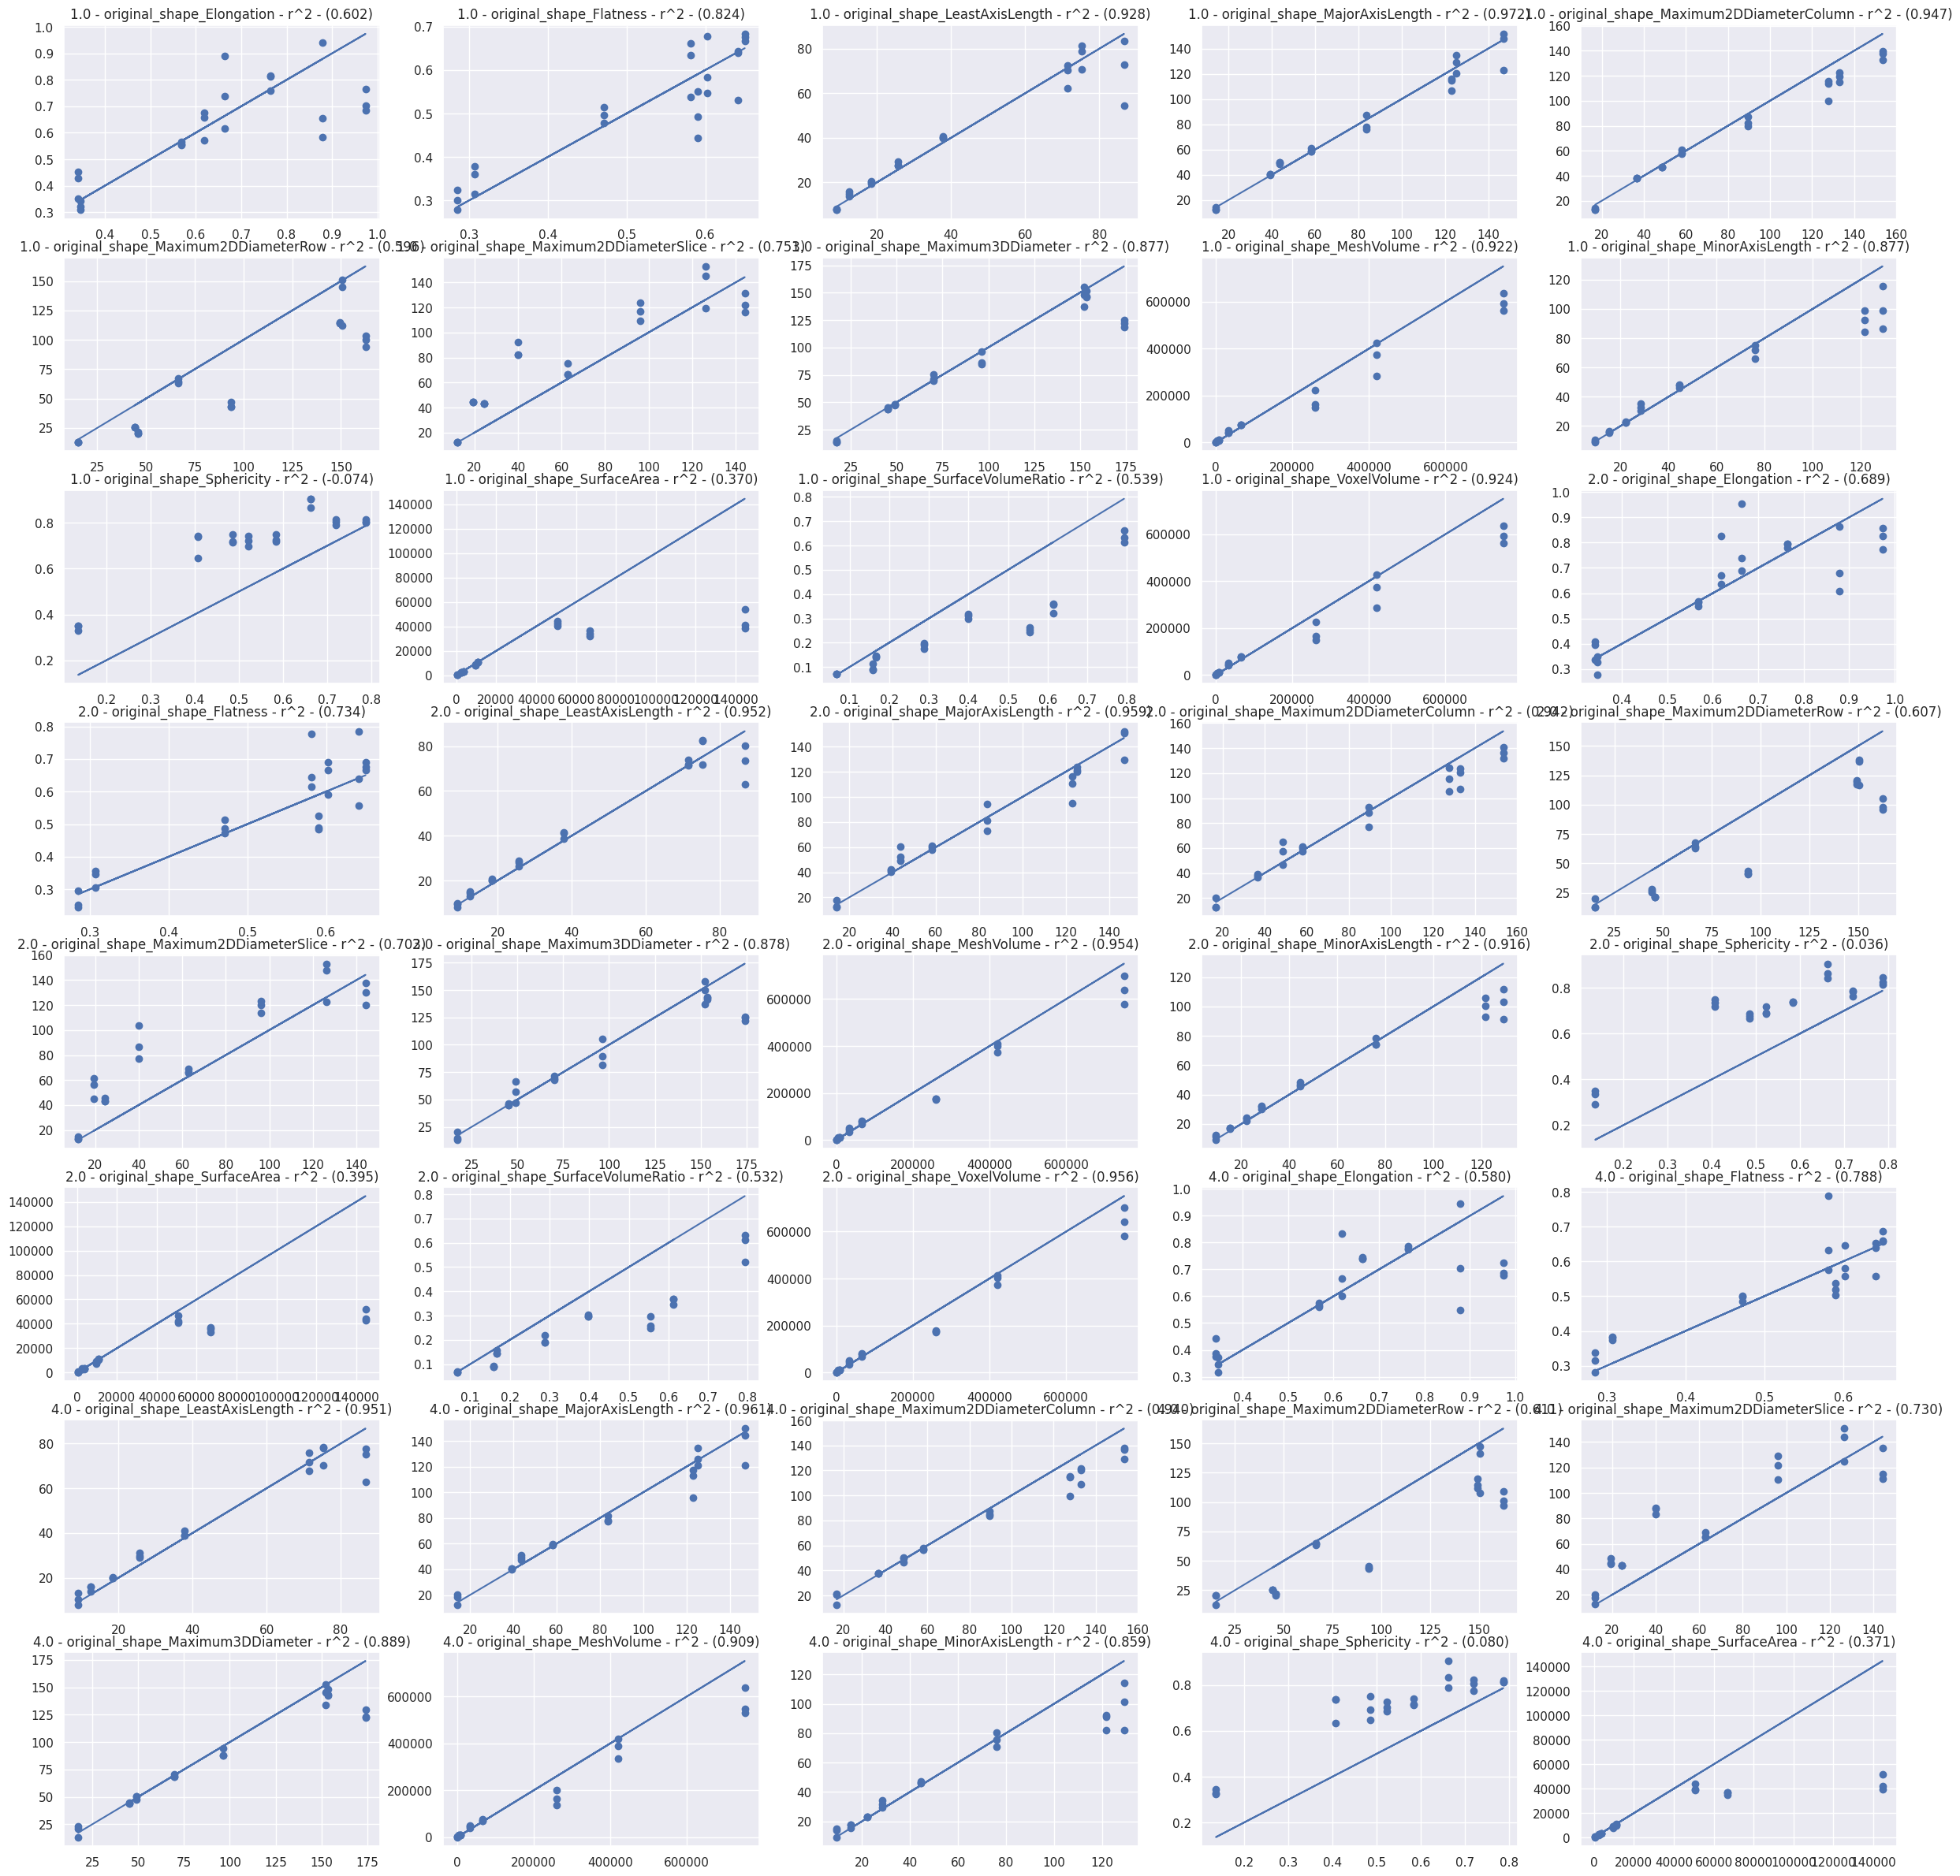

In [11]:
fig, ax = plt.subplots(8, 5, figsize=(30,30))
# Flatten the 2D array of axes into a 1D array of 40 elements
axes_flat = ax.flatten()
r2_vals = []

steps = 0
for i, cond in enumerate(cond_dfs):
    for j, col in enumerate(unique_column_values):
        # Prevent IndexError if your data exceeds 40 combinations
        if steps >= len(axes_flat):
            print("Warning: More data combinations than available subplots!")
            break
            
        col_rows = cond[cond["column"] == col]
        
        # Directly index the flattened axes
        current_ax = axes_flat[steps]
        
        current_ax.scatter(col_rows["desired_val"], col_rows["actual_val"])
        current_ax.plot(col_rows["desired_val"],col_rows["desired_val"])
        r2 = r2_score(col_rows["desired_val"], col_rows["actual_val"])
        current_ax.set_title(f"{unique_cond_values[i]} - {col} - r^2 - ({r2:.3f})")
        r2_vals.append({"r2":r2,"cond":unique_cond_values[i],"col":col})
        steps += 1

In [12]:
pd.DataFrame(r2_vals)

,r2,cond,col
0,0.602325,1.0,original_shape_Elongation
1,0.824104,1.0,original_shape_Flatness
2,0.928047,1.0,original_shape_LeastAxisLength
3,0.972459,1.0,original_shape_MajorAxisLength
4,0.946986,1.0,original_shape_Maximum2DDiameterColumn
5,0.596490,1.0,original_shape_Maximum2DDiameterRow
6,0.753058,1.0,original_shape_Maximum2DDiameterSlice
7,0.877215,1.0,original_shape_Maximum3DDiameter
8,0.922366,1.0,original_shape_MeshVolume
9,0.876543,1.0,original_shape_MinorAxisLength


In [15]:
for i, cond in enumerate(cond_dfs):
    r2s = []
    errors = []
    for j, col in enumerate(unique_column_values):
        col_rows = cond[cond["column"] == col]
        print(f"Cond: {unique_cond_values[i]} - Col: {col}")
        r2 = r2_score(col_rows["desired_val"], col_rows["actual_val"])
        print(f"R^2: {r2}")
        percent_error = (abs(col_rows['desired_val']-col_rows['actual_val'])/col_rows['desired_val']).mean() * 100
        print(f"Percent error: {percent_error}")

        print("=============")
        r2s.append(r2)
        errors.append(percent_error)
    print(sum(r2s) / len(r2s))
    print(f"Average error: {sum(errors) / len(errors)}")

Cond: 1.0 - Col: original_shape_Elongation
R^2: 0.6023253060592109
Percent error: 13.344254632165983
Cond: 1.0 - Col: original_shape_Flatness
R^2: 0.8241040579184364
Percent error: 8.866910959490298
Cond: 1.0 - Col: original_shape_LeastAxisLength
R^2: 0.9280469597947107
Percent error: 11.052306183156183
Cond: 1.0 - Col: original_shape_MajorAxisLength
R^2: 0.9724586886197669
Percent error: 6.769837266593565
Cond: 1.0 - Col: original_shape_Maximum2DDiameterColumn
R^2: 0.9469858659713486
Percent error: 9.288227610284931
Cond: 1.0 - Col: original_shape_Maximum2DDiameterRow
R^2: 0.5964902632238263
Percent error: 30.192636126800853
Cond: 1.0 - Col: original_shape_Maximum2DDiameterSlice
R^2: 0.7530582042686599
Percent error: 48.19613973666285
Cond: 1.0 - Col: original_shape_Maximum3DDiameter
R^2: 0.8772154239146268
Percent error: 9.221442076223026
Cond: 1.0 - Col: original_shape_MeshVolume
R^2: 0.9223661700991751
Percent error: 26.59104301852248
Cond: 1.0 - Col: original_shape_MinorAxisLength

In [9]:
from sklearn.metrics import r2_score

score = r2_score(df["desired_val"], df["actual_val"])

In [15]:
residuals = abs(df["desired_val"]-df["actual_val"])

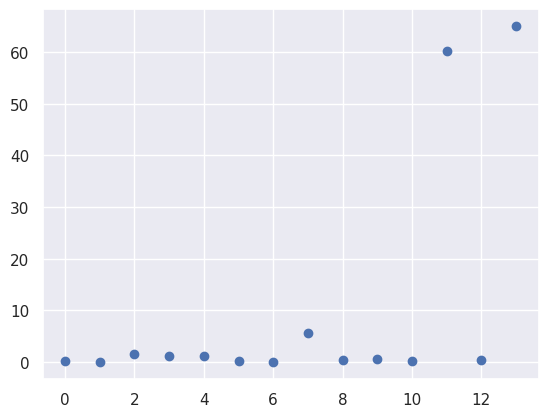

In [23]:
plt.scatter(np.arange(0,len(residuals)),residuals)

In [16]:
percent_error = residuals/df["desired_val"]

In [18]:
df["percent_error"] = percent_error*100

/local/rpinise1/3754629/ipykernel_3169481/3553926432.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["percent_error"] = percent_error*100


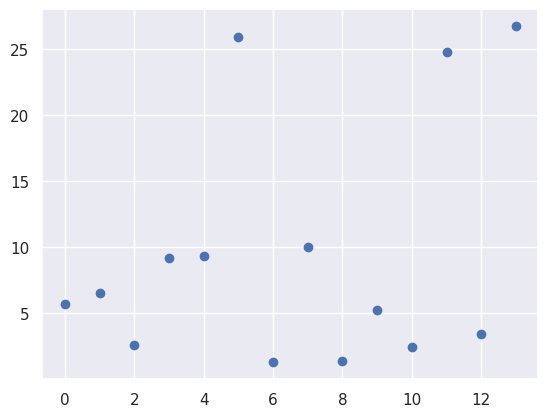

In [25]:
plt.scatter(np.arange(0,len(df["percent_error"])),df["percent_error"])

In [20]:
import numpy as np
from scipy import stats

def f_test_regression(y_true, y_pred, num_predictors=1):
    n = len(y_true)
    y_mean = np.mean(y_true)
    
    # Calculate Sum of Squares
    ss_reg = np.sum((y_pred - y_mean)**2)
    ss_res = np.sum((y_true - y_pred)**2)
    
    # Degrees of freedom
    df_reg = num_predictors
    df_res = n - num_predictors - 1
    
    # Mean Squares
    ms_reg = ss_reg / df_reg
    ms_res = ss_res / df_res
    
    # F-statistic
    f_stat = ms_reg / ms_res
    
    # P-value from F-distribution
    p_value = 1 - stats.f.cdf(f_stat, df_reg, df_res)
    
    return f_stat, p_value

# Usage
f_val, p_val = f_test_regression(df["desired_val"], df["actual_val"], num_predictors=1)
print(f"F-statistic: {f_val:.4f}, P-value: {p_val:.4e}")

F-statistic: 77.9043, P-value: 1.3557e-06


In [26]:
df

,column,desired_val,actual_val,percent_error
1,volume_ml,4.662286,4.929,5.720676
2,volume_ml,0.517142,0.551,6.547129
3,volume_ml,57.272589,55.789,2.590399
4,volume_ml,13.027158,14.227,9.210309
5,volume_ml,11.737662,12.830,9.306263
6,volume_ml,1.089673,1.372,25.909385
7,volume_ml,1.089673,1.104,1.314841
8,volume_ml,57.272589,51.548,9.995338
9,volume_ml,29.671052,29.266,1.365141
10,volume_ml,12.503197,11.847,5.248232
